# Learning a latent vector field from item responses

The [static](tutorial_static.ipynb) and [dynamic](tutorial_dynamic.ipynb) tutorials describe how latent traits vary *across people* and *over time*. Here we ask a different question: **which dynamical rule moves the traits?** We assume that every respondent's two latent traits follow the same autonomous differential equation

$$\frac{d\mathbf z_i(t)}{dt} = f_\phi\big(\mathbf z_i(t)\big), \qquad \mathbf z_i(0) \sim \mathcal N(\mathbf 0, 2^2 I),$$

where $f_\phi$ is a small neural network (a **neural ODE**). Respondents differ only in their starting point. The traits are measured with binary items through a two-parameter logistic (2PL) model,

$$P(Y_{ijt}=1)=\operatorname{logit}^{-1}\!\left(d_j + \mathbf a_j^\top \mathbf z_i(t)\right).$$

`dynamirt` handles the measurement model. We only supply the latent part: a function that integrates the ODE and returns $\mathbf z_i(t)$ for every response row. The network is written in [Equinox](https://docs.kidger.site/equinox/) and integrated with [Diffrax](https://docs.kidger.site/diffrax/).

The simulated dynamics have a **limit cycle**: trajectories starting inside or outside the unit circle are attracted to it and then keep rotating. The network contains no knowledge of this; it has to learn the field from binary responses alone. We fit the model twice: first with a confirmatory loading pattern, then with an exploratory sparsity prior.

Each fit runs 10,000 SVI steps with an ODE solve in every step. A GPU is recommended.

In [1]:
import logging
logging.getLogger("jax._src.xla_bridge").setLevel(logging.CRITICAL)

import jax

# Double precision keeps the adaptive ODE solver and its gradients well behaved.
jax.config.update("jax_enable_x64", True)

import diffrax as dfx
import equinox as eqx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from matplotlib.colors import Normalize
from numpyro.contrib.module import eqx_module
from numpyro.optim import ClippedAdam

from dynamirt import Confirmatory, CustomTerm, Sparsity, dynamirt, fit_svi
from dynamirt.diagnostics import item_curves, plot_item_curves, plot_loadings

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

## 1. Simulate respondents on a limit cycle

The true field is a Hopf oscillator. Written directly in terms of the two traits $z_1$ (`latent_0`) and $z_2$ (`latent_1`), it is

$$\frac{dz_1}{dt} = \alpha\,(1 - z_1^2 - z_2^2)\,z_1 - \omega z_2, \qquad \frac{dz_2}{dt} = \omega z_1 + \alpha\,(1 - z_1^2 - z_2^2)\,z_2,$$

with $\alpha=0.15$ and $\omega=1.5$. The $\omega$ terms rotate the state around the origin. The factor $\alpha(1 - z_1^2 - z_2^2)$ pushes states outward inside the unit circle and inward outside it, so every trajectory except the one starting exactly at the origin settles onto the unit circle: a limit cycle. One rotation takes $2\pi/\omega \approx 4.2$ time units.

We simulate 100 respondents whose starting points lie at a random angle and a random distance between 0 and 5 from the origin, and solve these equations with Diffrax. Everyone is observed at the same 101 time points between 0 and 10. At each time point they answer 24 binary items. Each item mainly measures one trait, and six items have a weaker cross-loading on the other trait. The simulation code is collapsible.

In [2]:
n_people, n_items, n_latent = 100, 24, 2
item_names = [f"item_{j}" for j in range(n_items)]
latent_names = [f"latent_{k}" for k in range(n_latent)]
observed_times = np.linspace(0, 10, 101)
ALPHA, OMEGA = 0.15, 1.5


def hopf_field(z):
    """True velocity dz/dt at states z with shape (..., 2)."""
    z1, z2 = z[..., 0], z[..., 1]
    radial = ALPHA * (1 - z1**2 - z2**2)
    return jnp.stack([radial * z1 - OMEGA * z2, OMEGA * z1 + radial * z2], axis=-1)


# Starting points: random distance in [0, 5) and random angle around the origin.
key_r, key_phi = jax.random.split(jax.random.key(42))
r0 = np.asarray(jax.random.uniform(key_r, (n_people,), minval=0.0, maxval=5.0))
phi0 = np.asarray(jax.random.uniform(key_phi, (n_people,), minval=0.0, maxval=2 * np.pi))
z0_true = np.stack([r0 * np.cos(phi0), r0 * np.sin(phi0)], axis=-1)

# Solve the equations above for everyone at once (tight tolerances: this is the truth).
solution = dfx.diffeqsolve(
    dfx.ODETerm(lambda t, z, args: hopf_field(z)), dfx.Tsit5(),
    t0=observed_times[0], t1=observed_times[-1], dt0=0.01, y0=jnp.asarray(z0_true),
    saveat=dfx.SaveAt(ts=jnp.asarray(observed_times)),
    stepsize_controller=dfx.PIDController(rtol=1e-8, atol=1e-8),
)
true_states = np.asarray(solution.ys).swapaxes(0, 1)  # (person, time, latent)

# 2PL items: a balanced main factor per item, one pure item per factor,
# and weaker positive or negative cross-loadings on six other items.
rng = np.random.default_rng(123)
primary = np.arange(n_items) % 2
rng.shuffle(primary)
loadings_true = np.zeros((n_items, n_latent))
loadings_true[np.arange(n_items), primary] = rng.uniform(0.8, 1.8, size=n_items)
pure_items = [np.flatnonzero(primary == k)[0] for k in range(n_latent)]
cross = rng.choice(np.setdiff1d(np.arange(n_items), pure_items), size=6, replace=False)
loadings_true[cross, 1 - primary[cross]] = rng.uniform(0.25, 0.65, size=6) * rng.choice([-1.0, 1.0], size=6)
intercepts_true = rng.uniform(-1.0, 1.0, size=n_items)

logits = true_states @ loadings_true.T + intercepts_true
probabilities = 1 / (1 + np.exp(-logits))
# Responses are drawn in (time, person, item) order, then stored per person.
Y = rng.binomial(1, probabilities.swapaxes(0, 1)).swapaxes(0, 1)  # (person, time, item)

`dynamirt` expects one response row per respondent–time observation. We flatten the `(person, time, item)` array and record which respondent and which time point each row belongs to. `time_idx` indexes `observed_times`; the model will use it to pick the matching ODE solution.

To check forecasts, we hold out the last 20% of the time points (t ≥ 8) for every respondent. Setting those responses to `np.nan` removes them from the likelihood. The ODE is still solved over the whole time range, so the fitted model predicts the held-out period.

We also choose three example respondents with small, medium, and large starting radii for the plots below.

In [3]:
n_times = len(observed_times)
responses = Y.reshape(-1, n_items).astype(float)          # (n_people * n_times, n_items)
covariates = {
    "respondent_id": np.repeat(np.arange(n_people), n_times),
    "time_idx": np.tile(np.arange(n_times), n_people),
}

train_stop = int(0.8 * n_times)                           # first 80 time points: t < 8
train_responses = np.where(covariates["time_idx"][:, None] < train_stop, responses, np.nan)

example_respondents = [int(np.argmin(np.abs(r0 - r))) for r in (0.3, 1.8, 3.2)]

The left panel shows the true vector field. The dashed circle is the limit cycle. On the right are the true trajectories of all respondents: they spiral outward from the center or inward from outside and settle onto the same cycle.

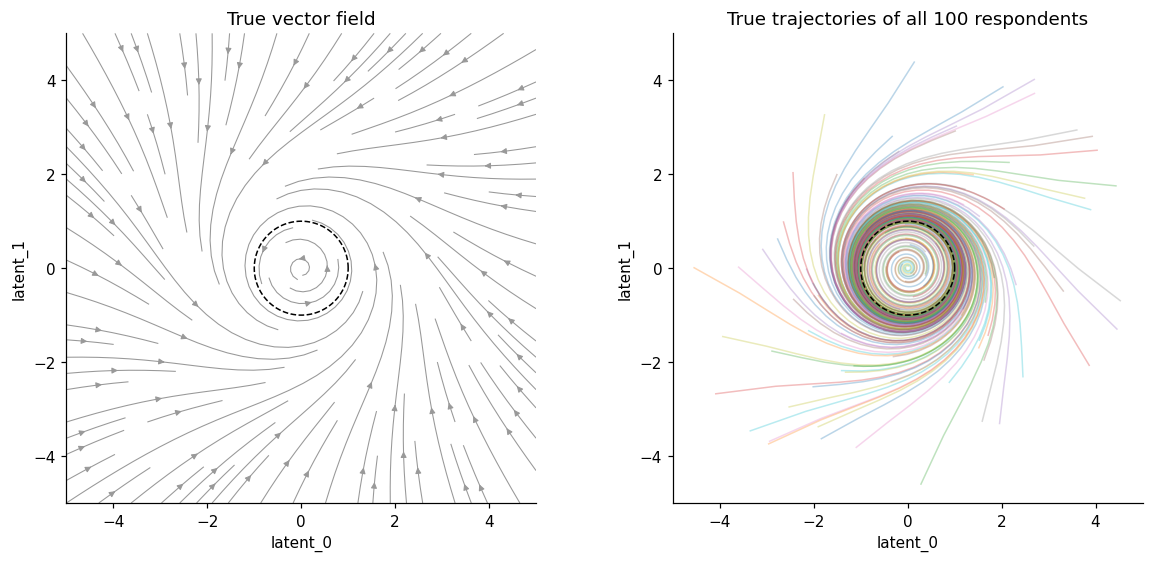

In [4]:
circle = np.linspace(0, 2 * np.pi, 200)
lim = 5
axis = np.linspace(-lim, lim, 40)
velocity = np.asarray(hopf_field(np.stack(np.meshgrid(axis, axis), axis=-1)))

fig, axes = plt.subplots(1, 2, figsize=(11, 5), layout="constrained")
axes[0].streamplot(axis, axis, velocity[..., 0], velocity[..., 1], color="0.6",
                   density=1.0, linewidth=0.7, arrowsize=0.8)
axes[0].set_title("True vector field")
for person, path in enumerate(true_states):
    axes[1].plot(*path.T, color=f"C{person % 10}", alpha=0.3, linewidth=1)
axes[1].set_title(f"True trajectories of all {n_people} respondents")
for ax in axes:
    ax.plot(np.cos(circle), np.sin(circle), "--", color="black", linewidth=1)
    ax.set(xlabel=latent_names[0], ylabel=latent_names[1],
           xlim=(-lim, lim), ylim=(-lim, lim), aspect="equal")
plt.show()

The model never sees these trajectories, only the binary responses. On the right, each column is one time point and each row one item, with dark squares for positive responses. Items are grouped by their main factor (dashed line). The cycles are visible as bands in the responses, but individual answers are noisy. Responses to the right of the black line are held out.

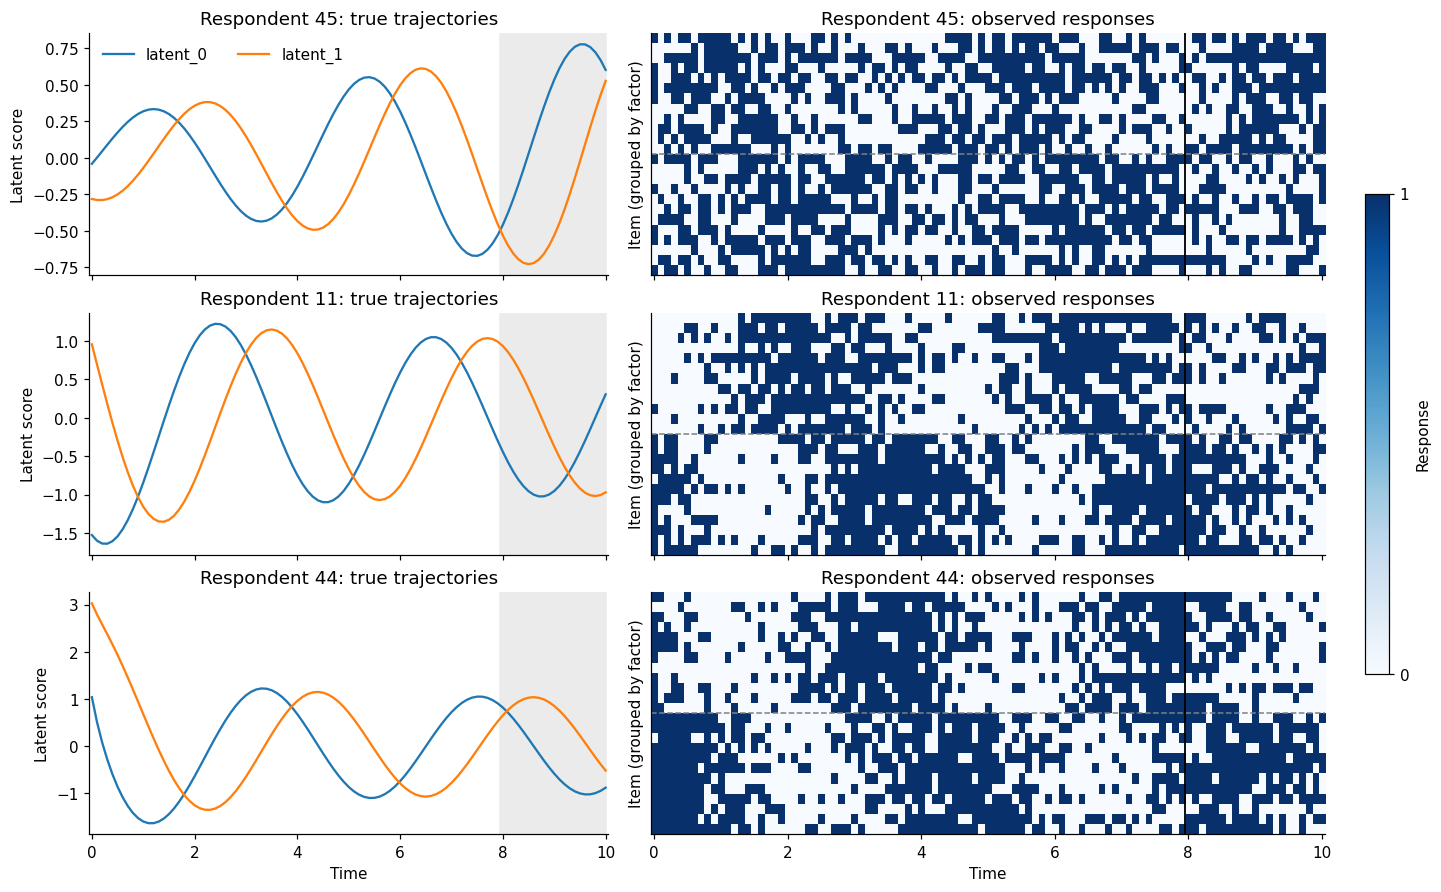

In [5]:
item_order = np.argsort(primary, kind="stable")
dt = observed_times[1] - observed_times[0]
forecast_start = observed_times[train_stop] - dt / 2

fig, axes = plt.subplots(3, 2, figsize=(13, 8), sharex=True, layout="constrained",
                         gridspec_kw={"width_ratios": [1, 1.3]})
for row, person in enumerate(example_respondents):
    trajectory_ax, response_ax = axes[row]
    for factor, latent in enumerate(latent_names):
        trajectory_ax.plot(observed_times, true_states[person, :, factor],
                           color=f"C{factor}", label=latent)
    trajectory_ax.axvspan(forecast_start, observed_times[-1], color="0.92", zorder=-1)
    trajectory_ax.set(title=f"Respondent {person}: true trajectories", ylabel="Latent score")

    image = response_ax.imshow(
        Y[person][:, item_order].T, cmap="Blues", vmin=0, vmax=1,
        aspect="auto", interpolation="nearest",
        extent=(observed_times[0] - dt / 2, observed_times[-1] + dt / 2, n_items - 0.5, -0.5),
    )
    response_ax.axhline(np.sum(primary == 0) - 0.5, color="0.5", linestyle="--", linewidth=1)
    response_ax.axvline(forecast_start, color="black", linewidth=1.2)
    response_ax.set(title=f"Respondent {person}: observed responses",
                    ylabel="Item (grouped by factor)", yticks=[])

axes[0, 0].legend(frameon=False, ncol=2)
for ax in axes[-1]:
    ax.set_xlabel("Time")
fig.colorbar(image, ax=axes[:, 1], ticks=[0, 1], label="Response", shrink=0.6)
plt.show()

## 2. A neural ODE as a latent term

The vector field $f_\phi$ is an Equinox MLP that maps a 2D state to a 2D velocity (two hidden layers of 32 SiLU units). Diffrax integrates it with an adaptive Runge–Kutta solver (`Tsit5`). An Equinox module is a JAX pytree, so the network is passed to the solver through `args`.

`CustomTerm` lets us add our own latent component to a `dynamirt` model. Its function receives a `ModelContext` and the number of latent dimensions, and must return one latent score per response row, i.e. an array of shape `(n_obs, n_latent)`. Inside `node_term` we

1. register the network weights with NumPyro through `eqx_module`,
2. sample one initial state per respondent,
3. solve the ODE for all respondents at once, and
4. pick the solution at each row's respondent and time point.

`eqx_module` registers the weights as a `numpyro.param`. SVI therefore learns a **point estimate** of the field, while the initial states and item parameters get an approximate posterior distribution. The uncertainty shown below is therefore conditional on the fitted field.

In [6]:
vector_field = eqx.nn.MLP(
    in_size=2, out_size=2, width_size=32, depth=2,
    activation=jax.nn.silu, key=jax.random.key(0),
)


def rhs(t, z, network):
    return jax.vmap(network)(z)  # z has shape (n_respondents, 2)


def solve(network, z0, save_times, **kwargs):
    return dfx.diffeqsolve(
        dfx.ODETerm(rhs), dfx.Tsit5(),
        t0=save_times[0], t1=save_times[-1], dt0=0.01, y0=z0, args=network,
        saveat=dfx.SaveAt(ts=save_times),
        stepsize_controller=dfx.PIDController(rtol=1e-4, atol=1e-6),
        max_steps=16384, **kwargs,
    )


times = jnp.asarray(observed_times)


def node_term(ctx, n_latent):
    respondent, n_respondents = ctx.factorize("respondent_id")
    network = eqx_module("vector_field", vector_field)
    z0 = numpyro.sample(
        "initial_states",
        dist.Normal(0, 2.0).expand([n_respondents, n_latent]).to_event(2),
    )
    paths = solve(network, z0, times).ys           # (n_times, n_respondents, n_latent)
    return paths[ctx.covariates["time_idx"], respondent]

The plots below use ordinary Matplotlib code, collected in the next (collapsible) cell so we can reuse it for both fits.

In [7]:
COLORS = ["#0072B2", "#D55E00", "#009E73"]  # one color per example respondent


def evaluate(network, points):
    """Evaluate the network at states with shape (..., 2)."""
    flat = jnp.asarray(points.reshape(-1, 2))
    return np.asarray(jax.vmap(network)(flat)).reshape(points.shape)


def make_grid(lo, hi, n=40):
    x, y = np.linspace(lo[0], hi[0], n), np.linspace(lo[1], hi[1], n)
    return x, y, np.stack(np.meshgrid(x, y), axis=-1)


def phase_axes(ax, title, lim=None):
    ax.set(title=title, xlabel=latent_names[0], ylabel=latent_names[1])
    if lim is not None:
        ax.set(xlim=(-lim, lim), ylim=(-lim, lim))
    ax.set_aspect("equal")


def plot_loss(result, title):
    losses = np.asarray(result.inference.result.losses)
    window = 200
    smoothed = np.convolve(losses, np.ones(window) / window, mode="valid")
    fig, ax = plt.subplots(figsize=(8, 3), layout="constrained")
    ax.plot(np.arange(1, len(losses) + 1), losses, color="C0", alpha=0.2, linewidth=0.7)
    ax.plot(np.arange(window, len(losses) + 1), smoothed, color="C0",
            label=f"{window}-step moving average")
    ax.set(yscale="log", xlabel="Optimization step",
           ylabel="Negative ELBO (lower is better)", title=title)
    ax.legend(frameon=False)
    ax.grid(alpha=0.15)
    plt.show()


def plot_measurement(result, idata, groups):
    """Loading heatmap plus item curves for the items in groups[k] on each factor k."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 7), layout="constrained",
                             gridspec_kw={"width_ratios": [1.1, 1, 1]})
    plot_loadings(idata, ax=axes[0], text_kwargs={"fontsize": 7})
    axes[0].set_title("Item discriminations\nMedian and 95% HDI")
    colors = plt.get_cmap("tab20").colors
    for factor, (latent, ax) in enumerate(zip(latent_names, axes[1:])):
        curves = item_curves(result, posterior=idata["posterior"], latent=[latent])
        for color, item in zip(colors, groups[factor]):
            plot_item_curves(
                curves, item=item_names[item], category=1, ax=ax,
                line_kwargs={"color": color, "label": item_names[item], "linewidth": 1.5},
                fill_kwargs={"alpha": 0.1},
            )
        ax.set(title=f"Items loading mainly on {latent}", xlabel=latent,
               ylabel="P(response = 1)", ylim=(0, 1))
        ax.grid(alpha=0.15)
        ax.legend(frameon=False, fontsize=7, ncol=2, loc="upper left")
    plt.show()


def plot_fields(network, paths, lim=3.5):
    """True field next to the fitted field, each in its own coordinates."""
    x, y, grid = make_grid((-lim, -lim), (lim, lim))
    true_velocity = np.asarray(hopf_field(grid))
    fitted_velocity = evaluate(network, grid)
    norm = Normalize(0, np.linalg.norm(true_velocity, axis=-1).max())

    fig, axes = plt.subplots(1, 2, figsize=(11, 5), layout="constrained")
    for ax, velocity, states, title in [
        (axes[0], true_velocity, true_states, "True field"),
        (axes[1], fitted_velocity, paths[0], "Fitted field (one draw of trajectories)"),
    ]:
        stream = ax.streamplot(
            x, y, velocity[..., 0], velocity[..., 1],
            color=np.linalg.norm(velocity, axis=-1), cmap="viridis", norm=norm,
            density=0.9, linewidth=0.7, arrowsize=0.7,
        )
        ax.plot(np.cos(circle), np.sin(circle), "--", color="0.3", linewidth=1)
        for color, person in zip(COLORS, example_respondents):
            ax.plot(*states[person].T, color=color, linewidth=1.6)
            ax.scatter(*states[person, 0], color=color, s=25, edgecolor="white", zorder=5)
        phase_axes(ax, title, lim)
    fig.colorbar(stream.lines, ax=axes, label="Speed", extend="max", shrink=0.8)
    plt.show()


def plot_all_trajectories(paths, lim=5):
    fig, axes = plt.subplots(1, 2, figsize=(11, 5), layout="constrained")
    for ax, states, title in [
        (axes[0], true_states, "True trajectories"),
        (axes[1], paths[0], "Fitted trajectories (one posterior draw)"),
    ]:
        for person, path in enumerate(states):
            ax.plot(*path.T, color=f"C{person % 10}", alpha=0.3, linewidth=1)
        ax.plot(np.cos(circle), np.sin(circle), "--", color="black", linewidth=1)
        phase_axes(ax, title, lim)
    plt.show()


def plot_respondents(network, paths, n_draws=20):
    """Posterior draws for the example respondents: phase plane and both traits over time."""
    examples = paths[:, example_respondents].reshape(-1, 2)
    lo, hi = examples.min(axis=0), examples.max(axis=0)
    x, y, grid = make_grid(lo - 0.15 * (hi - lo), hi + 0.15 * (hi - lo))
    velocity = evaluate(network, grid)

    fig, axes = plt.subplots(3, 3, figsize=(13, 10), layout="constrained")
    for row, (person, color) in enumerate(zip(example_respondents, COLORS)):
        draws = paths[:, person]  # (draw, time, latent)
        mean = draws.mean(axis=0)

        ax = axes[row, 0]
        ax.streamplot(x, y, velocity[..., 0], velocity[..., 1], color="0.8",
                      density=0.8, linewidth=0.6, arrowsize=0.7)
        ax.plot(draws[:n_draws, :, 0].T, draws[:n_draws, :, 1].T,
                color=color, alpha=0.3, linewidth=0.8)
        ax.plot(*mean.T, "--", color="black", linewidth=1)
        ax.scatter(draws[:n_draws, 0, 0], draws[:n_draws, 0, 1], color=color, s=10, zorder=5)
        phase_axes(ax, f"Respondent {person}")
        ax.set(xlim=(x[0], x[-1]), ylim=(y[0], y[-1]))

        for factor, latent in enumerate(latent_names):
            ax = axes[row, factor + 1]
            lower, upper = np.quantile(draws[..., factor], [0.05, 0.95], axis=0)
            ax.fill_between(observed_times, lower, upper, color=color, alpha=0.15,
                            label="90% interval")
            lines = ax.plot(observed_times, draws[:n_draws, :, factor].T,
                            color=color, alpha=0.3, linewidth=0.7)
            lines[0].set_label(f"{n_draws} posterior draws")
            ax.plot(observed_times, mean[:, factor], "--", color="black", linewidth=1,
                    label="Posterior mean")
            ax.axvspan(forecast_start, observed_times[-1], color="0.92", zorder=-1)
            ax.set(title=f"Respondent {person} · {latent}", xlabel="Time", ylabel="Latent score")
    axes[0, 1].legend(frameon=False, fontsize=8)
    plt.show()


def plot_rollouts(network, t_max=60):
    """Integrate the fitted field far beyond the data from rings of starting points."""
    radii = [0.4, 0.8, 1.3, 2.0]
    angles = np.linspace(0, 2 * np.pi, 4, endpoint=False)
    starts = np.array([[r * np.cos(a), r * np.sin(a)] for r in radii for a in angles])
    long_times = np.linspace(0, t_max, 601)
    solution = solve(network, jnp.asarray(starts), jnp.asarray(long_times), throw=False)
    rollouts = np.asarray(solution.ys)  # (time, start, latent)

    colors = plt.get_cmap("viridis")(np.linspace(0, 0.85, len(radii)))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained",
                             gridspec_kw={"width_ratios": [1, 1.6]})
    for k in range(len(starts)):
        group = k // len(angles)
        label = f"start distance {radii[group]}" if k % len(angles) == 0 else None
        axes[0].plot(*rollouts[:, k].T, color=colors[group], linewidth=0.7, alpha=0.8)
        axes[1].plot(long_times, rollouts[:, k, 0], color=colors[group], linewidth=0.8, label=label)
    phase_axes(axes[0], "Long rollouts")
    axes[1].axvspan(0, observed_times[-1], color="0.92", zorder=-1)
    axes[1].set(title=f"{latent_names[0]} over time (gray: observed time span)",
                xlabel="Time", ylabel=latent_names[0])
    axes[1].legend(frameon=False, fontsize=8, loc="upper right")
    plt.show()

## 3. Fit with a confirmatory loading pattern

We first assume that we know which items measure which trait. `Q` marks the allowed loadings, including the six cross-loadings. `positive` constrains each item's main loading to be positive, which fixes the direction of both factors. The scale of the traits is set by the prior on the initial states.

With `latent_fn=[CustomTerm("node", node_term)]` the ODE solution is the entire latent score, so we switch off the default row-level residual.

`fit_svi` uses an `AutoNormal` guide. We clip gradient norms because a large update to the network can make the ODE hard to solve, and we start the guide with small scales (`init_scale=0.05`).

In [8]:
Q = (loadings_true != 0).astype(int)
positive = np.zeros_like(Q, dtype=bool)
positive[np.arange(n_items), primary] = True

model = dynamirt(
    model_type="2PL",
    n_latent=n_latent,
    loadings=Confirmatory(Q, positive=positive),
    latent_fn=[CustomTerm("node", node_term)],
    include_residuals=False,
)

result = fit_svi(
    model, train_responses, covariates,
    num_steps=10_000,
    optim=ClippedAdam(step_size=1e-3, clip_norm=10.0),
    guide_kwargs={"init_scale": 0.05},
    rng_key=jax.random.key(0),
)

100%|██████████| 10000/10000 [03:10<00:00, 52.49it/s, init loss: 233941.6305, avg. loss [9501-10000]: 107034.1841]


A flattening loss suggests that the optimization has settled. The spikes early on come from large network updates; gradient clipping keeps them from derailing the fit.

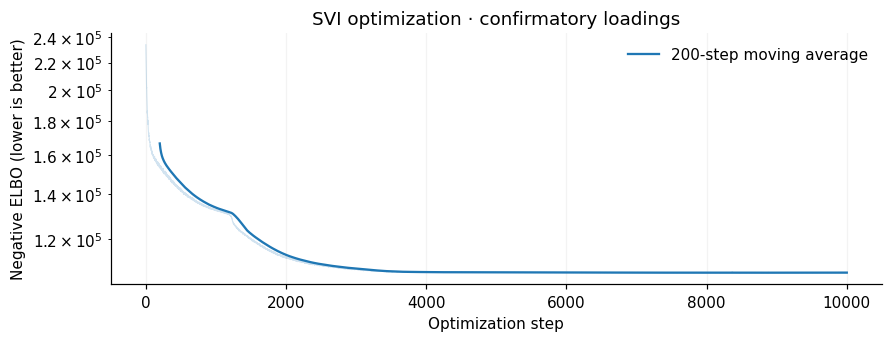

In [9]:
plot_loss(result, "SVI optimization · confirmatory loadings")

### Measurement model

`to_idata` draws from the fitted guide and labels the draws. The standard `dynamirt` plotting functions then show the loadings and item response curves, exactly as in the other tutorials. The curves show items whose main loading is on each factor, while the other trait is held at zero.

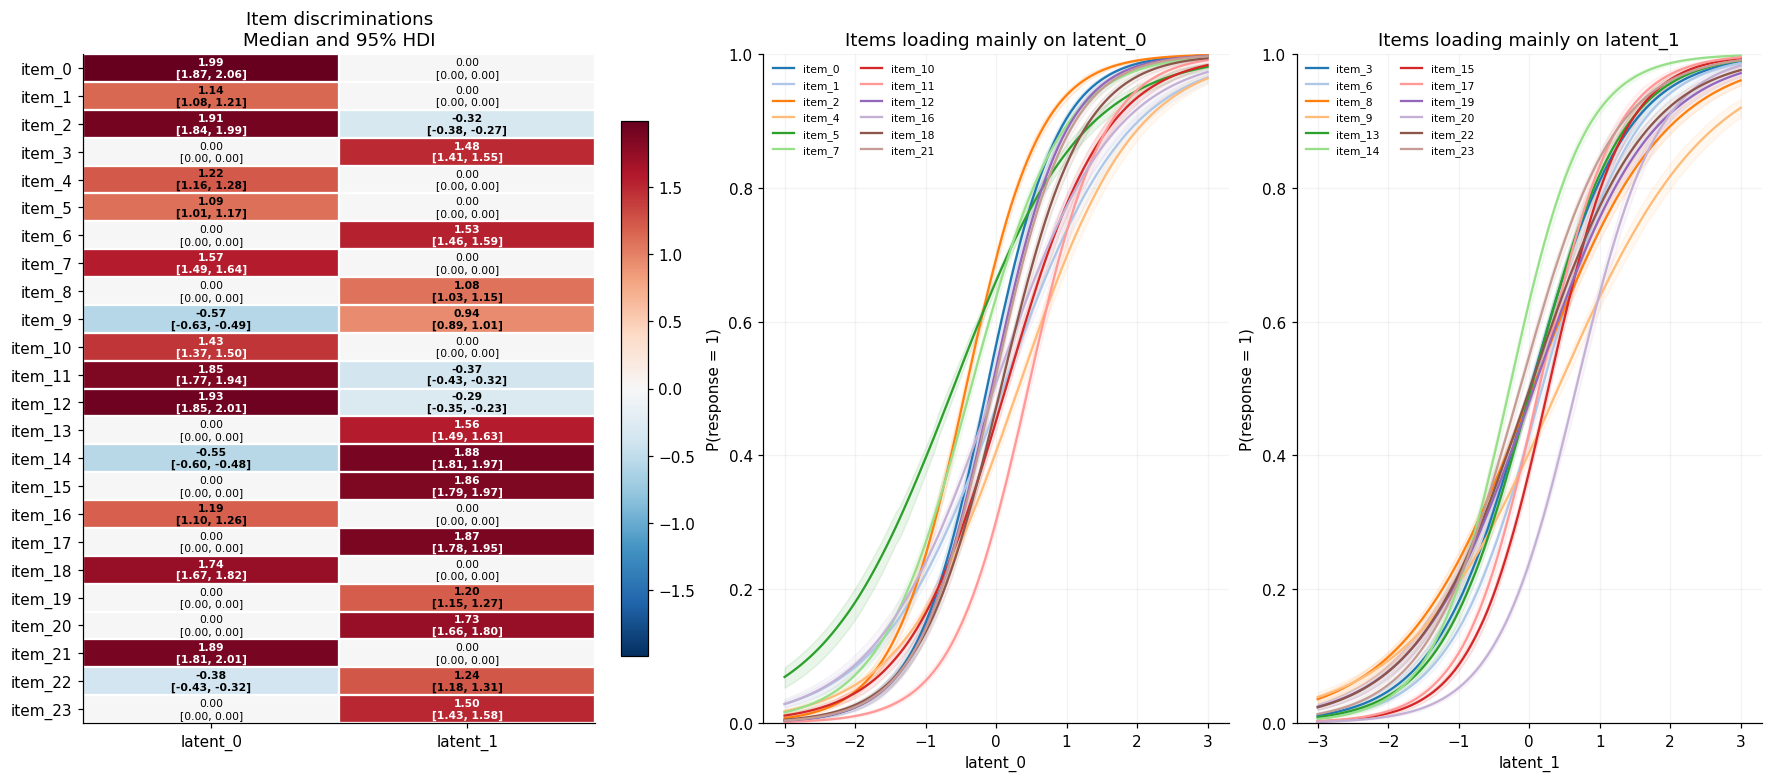

In [10]:
idata = result.to_idata(num_samples=100, coords={"item": item_names, "latent": latent_names})
plot_measurement(result, idata, groups=[np.flatnonzero(primary == k) for k in range(n_latent)])

### Trajectories from the fitted field

Each posterior draw of the initial states, combined with the fitted network, gives one set of trajectories. We rebuild the fitted network from the learned weights with `eqx.combine`, then solve the ODE for all draws and respondents in a single batch.

We solve the trajectories ourselves rather than reading `theta` from `idata`, because ArviZ's SVI conversion recomputes deterministic sites with the network's *initial* weights. The item parameters and initial states in `idata` are unaffected.

Averaging draws does not generally produce a solution of the ODE. We therefore plot individual draws where the field matters, and use the mean only as a summary.

In [11]:
def posterior_trajectories(result, idata):
    weights = result.inference.result.params["node.vector_field$params"]
    network = eqx.combine(weights, vector_field)  # learned weights + network structure
    z0 = idata["posterior"]["node.initial_states"].transpose("sample", ...).values
    paths = solve(network, jnp.asarray(z0.reshape(-1, 2)), times).ys  # (time, draw * person, latent)
    paths = np.asarray(paths).reshape(n_times, *z0.shape)
    return network, paths.transpose(1, 2, 0, 3)  # (draw, person, time, latent)


network, paths = posterior_trajectories(result, idata)

### Did we recover the vector field?

The fitted field is shown in its own coordinates, next to the true field. They are directly comparable only up to what the model identifies. The confirmatory loadings fix which trait is which and their direction, but the scale of the traits comes from the priors. If the fitted loadings are larger than the true ones, the fitted traits are correspondingly smaller, and the fitted cycle is smaller than the dashed unit circle (the true cycle).

The colors show speed on the true field's scale. The fitted field is only constrained where respondents actually went; far from the data it extrapolates freely.

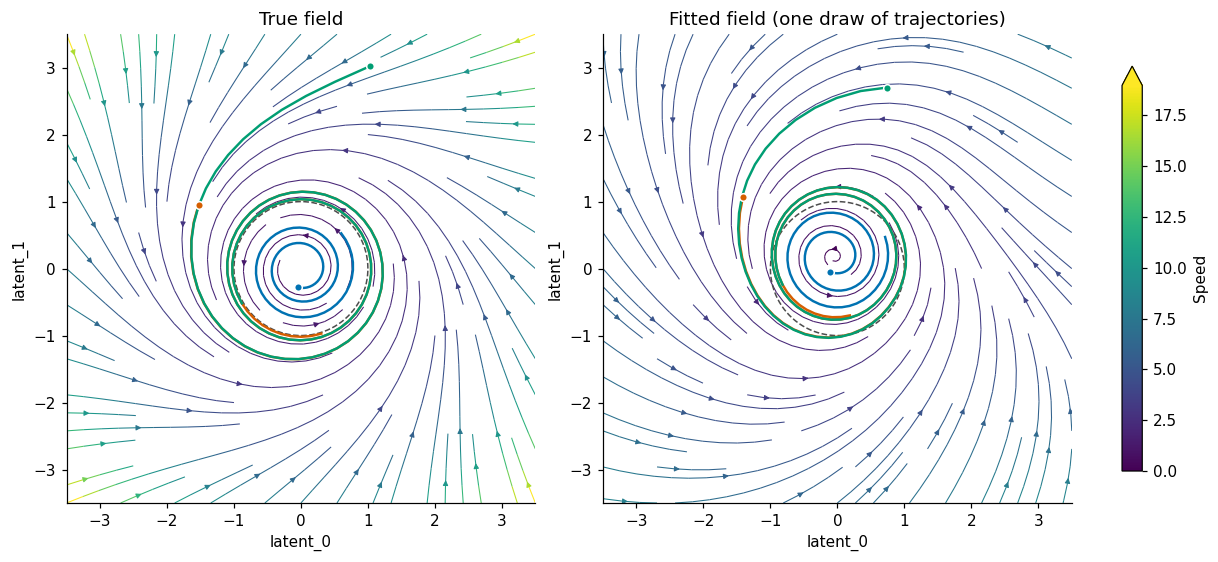

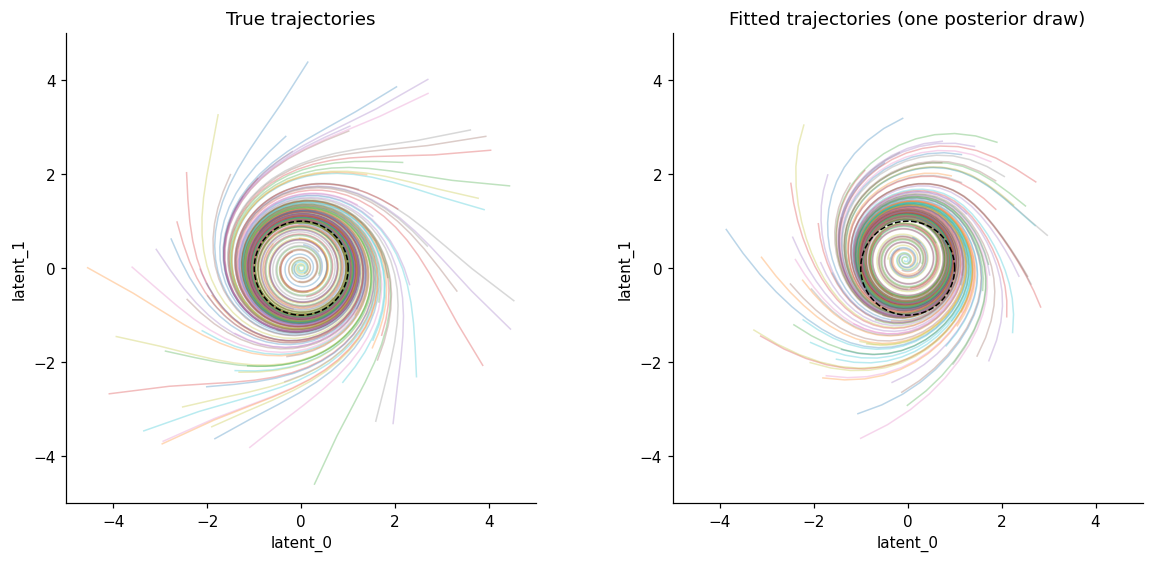

In [12]:
plot_fields(network, paths)
plot_all_trajectories(paths)

### Individual respondents

Thin lines are posterior draws, and each one is an exact solution of the fitted ODE. The dashed line is the posterior mean. The bands are pointwise 90% intervals. In the gray region no responses were used, so the trajectories there are forecasts.

Uncertainty is largest near the start, where the initial state has to be inferred from a few noisy responses. The draws then contract onto the cycle, because the attracting field pulls different starting points onto the same orbit.

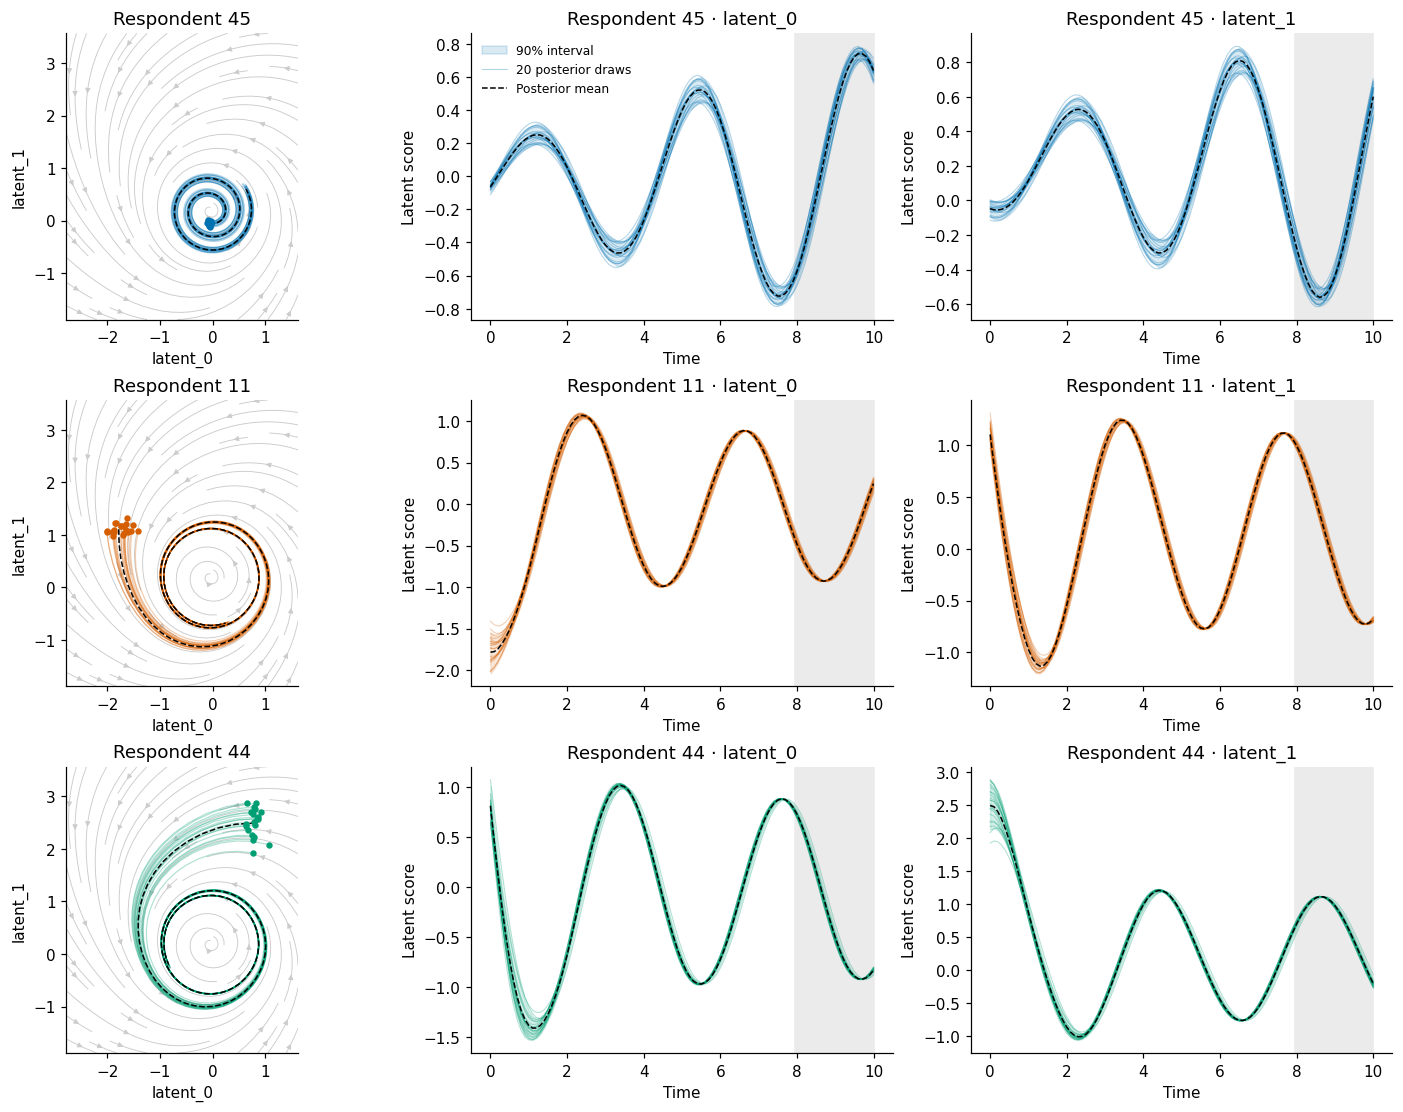

In [13]:
plot_respondents(network, paths)

### Is it really a limit cycle?

Ten time units cover only about two rotations. A slowly decaying spiral (a stable focus) could look similar over that window. We therefore integrate the fitted field for 60 time units from starting points at different distances from the origin, inside and outside the cycle. For a limit cycle, all trajectories should end up on the same closed orbit: in the right panel, every oscillation settles to the same amplitude. A stable focus would make the oscillations die out, and a center would keep a different amplitude for every starting point.

Everything beyond t = 10 (and any starting point far from the data) is extrapolation, so treat this as evidence rather than proof.

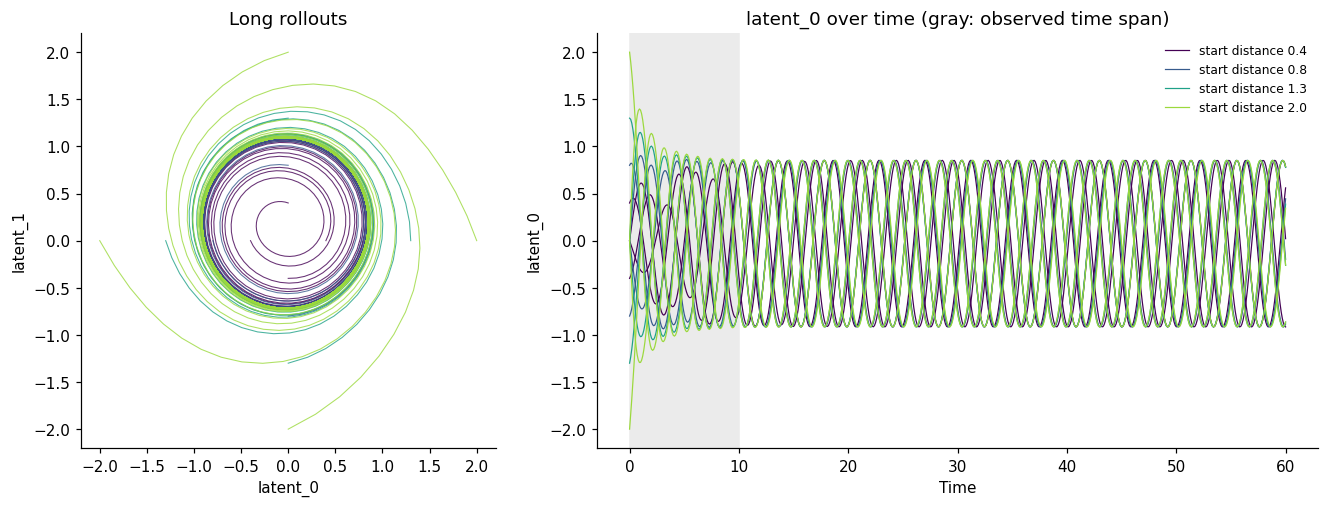

In [14]:
plot_rollouts(network)

## 4. Fit with sparse exploratory loadings

Now suppose we do not know the loading pattern. `Sparsity()` places a regularized horseshoe prior on a full loading matrix, which favors solutions where most items load on only one factor. No signs or factor labels are fixed, so the fitted axes may be swapped, mirrored, or rotated relative to the truth. `Sparsity` is still experimental in `dynamirt`.

Everything else, including the neural ODE term and the optimizer settings, stays the same. Only the `loadings` argument changes.

100%|██████████| 10000/10000 [04:00<00:00, 41.53it/s, init loss: 166450.9315, avg. loss [9501-10000]: 107206.1461]


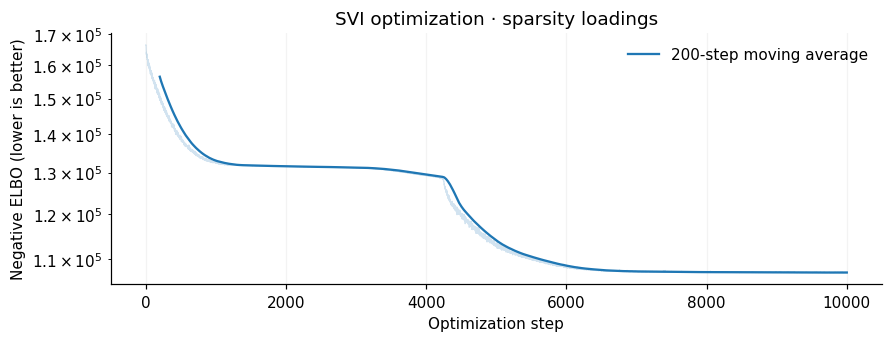

In [15]:
model_sparse = dynamirt(
    model_type="2PL",
    n_latent=n_latent,
    loadings=Sparsity(),
    latent_fn=[CustomTerm("node", node_term)],
    include_residuals=False,
)

result_sparse = fit_svi(
    model_sparse, train_responses, covariates,
    num_steps=10_000,
    optim=ClippedAdam(step_size=1e-3, clip_norm=10.0),
    guide_kwargs={"init_scale": 0.05},
    rng_key=jax.random.key(0),
)
plot_loss(result_sparse, "SVI optimization · sparsity loadings")

Without a Q matrix, we group items by their largest absolute median loading. Compare the heatmap with the confirmatory fit: a similar sparse pattern should appear, possibly with the factors swapped or with flipped signs.

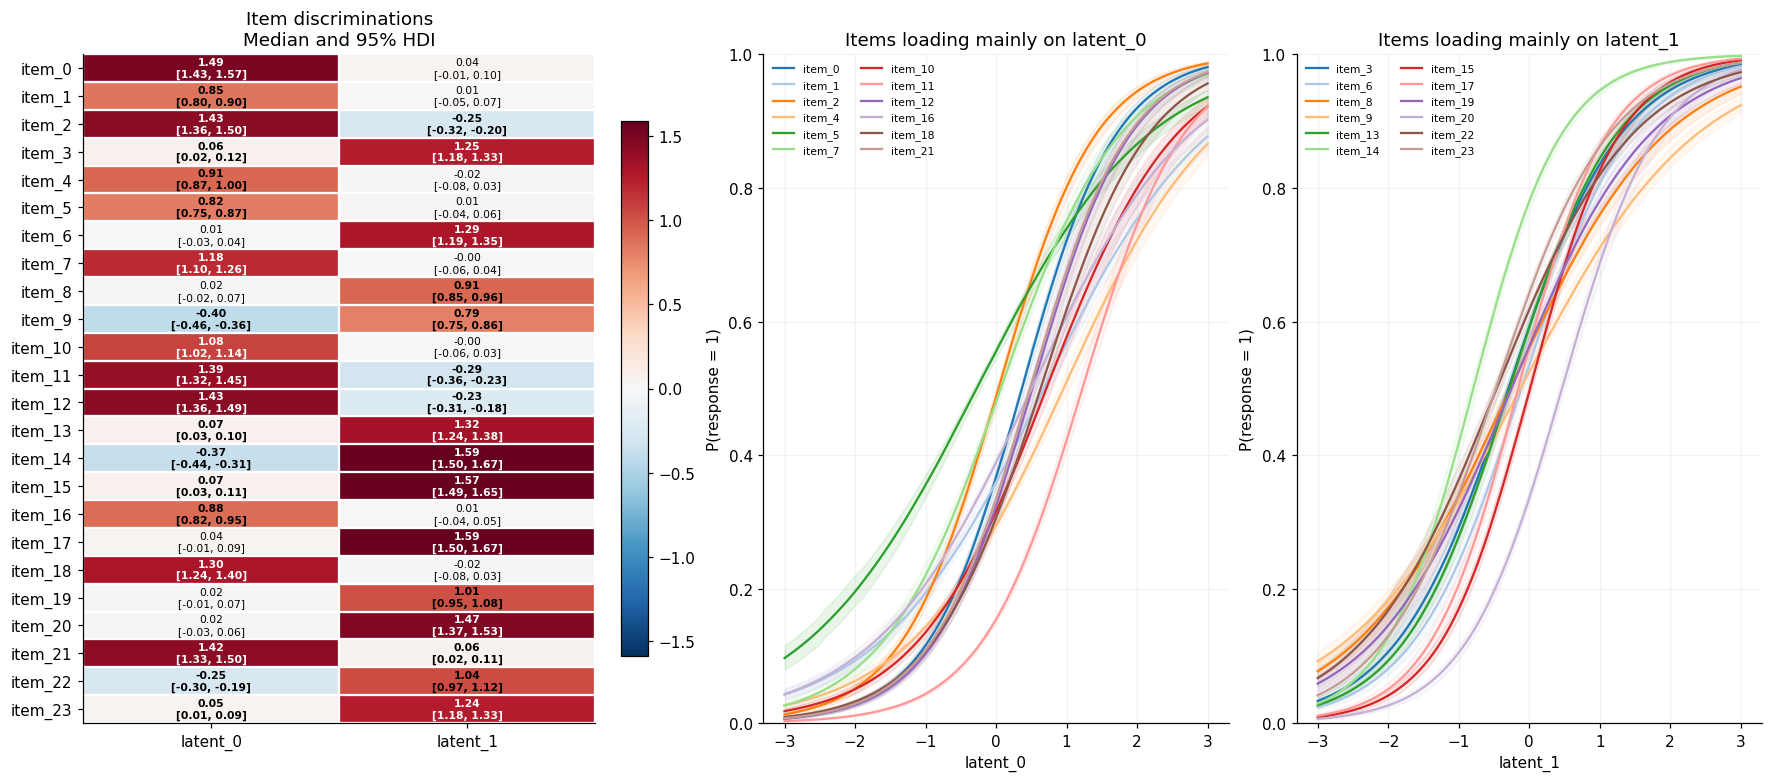

In [16]:
idata_sparse = result_sparse.to_idata(num_samples=100, coords={"item": item_names, "latent": latent_names})
median_loadings = idata_sparse["posterior"]["loadings"].median("sample").values
main_factor = np.abs(median_loadings).argmax(axis=1)
plot_measurement(result_sparse, idata_sparse,
                 groups=[np.flatnonzero(main_factor == k) for k in range(n_latent)])

As before, the fitted field is shown in its own coordinates. Had the sparse fit swapped or mirrored the factors, the field and trajectories below would appear swapped or mirrored too.

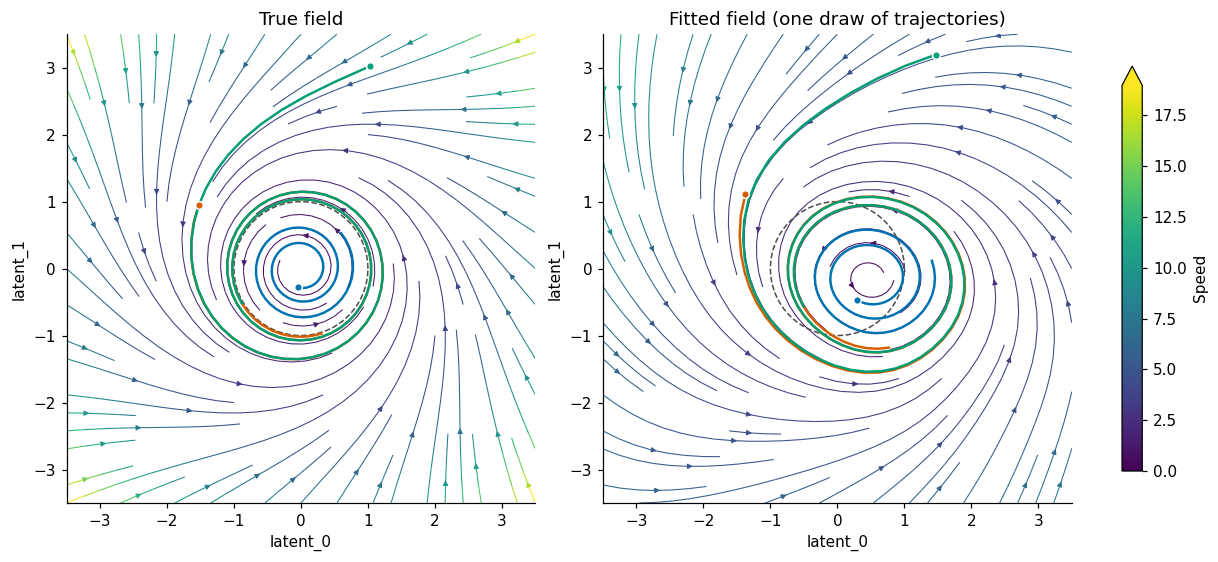

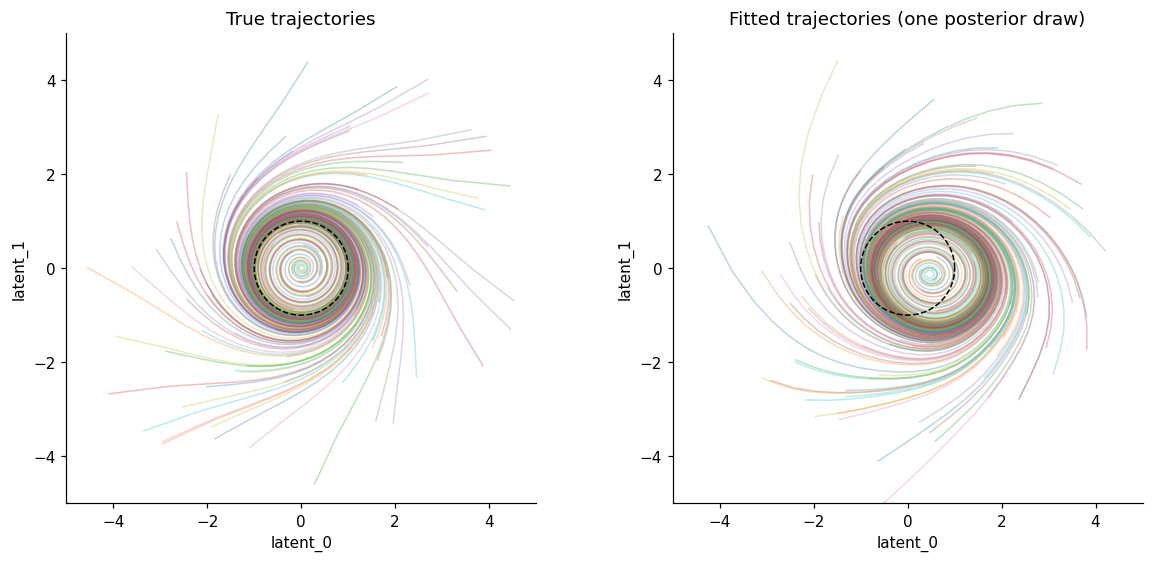

In [17]:
network_sparse, paths_sparse = posterior_trajectories(result_sparse, idata_sparse)
plot_fields(network_sparse, paths_sparse)
plot_all_trajectories(paths_sparse)

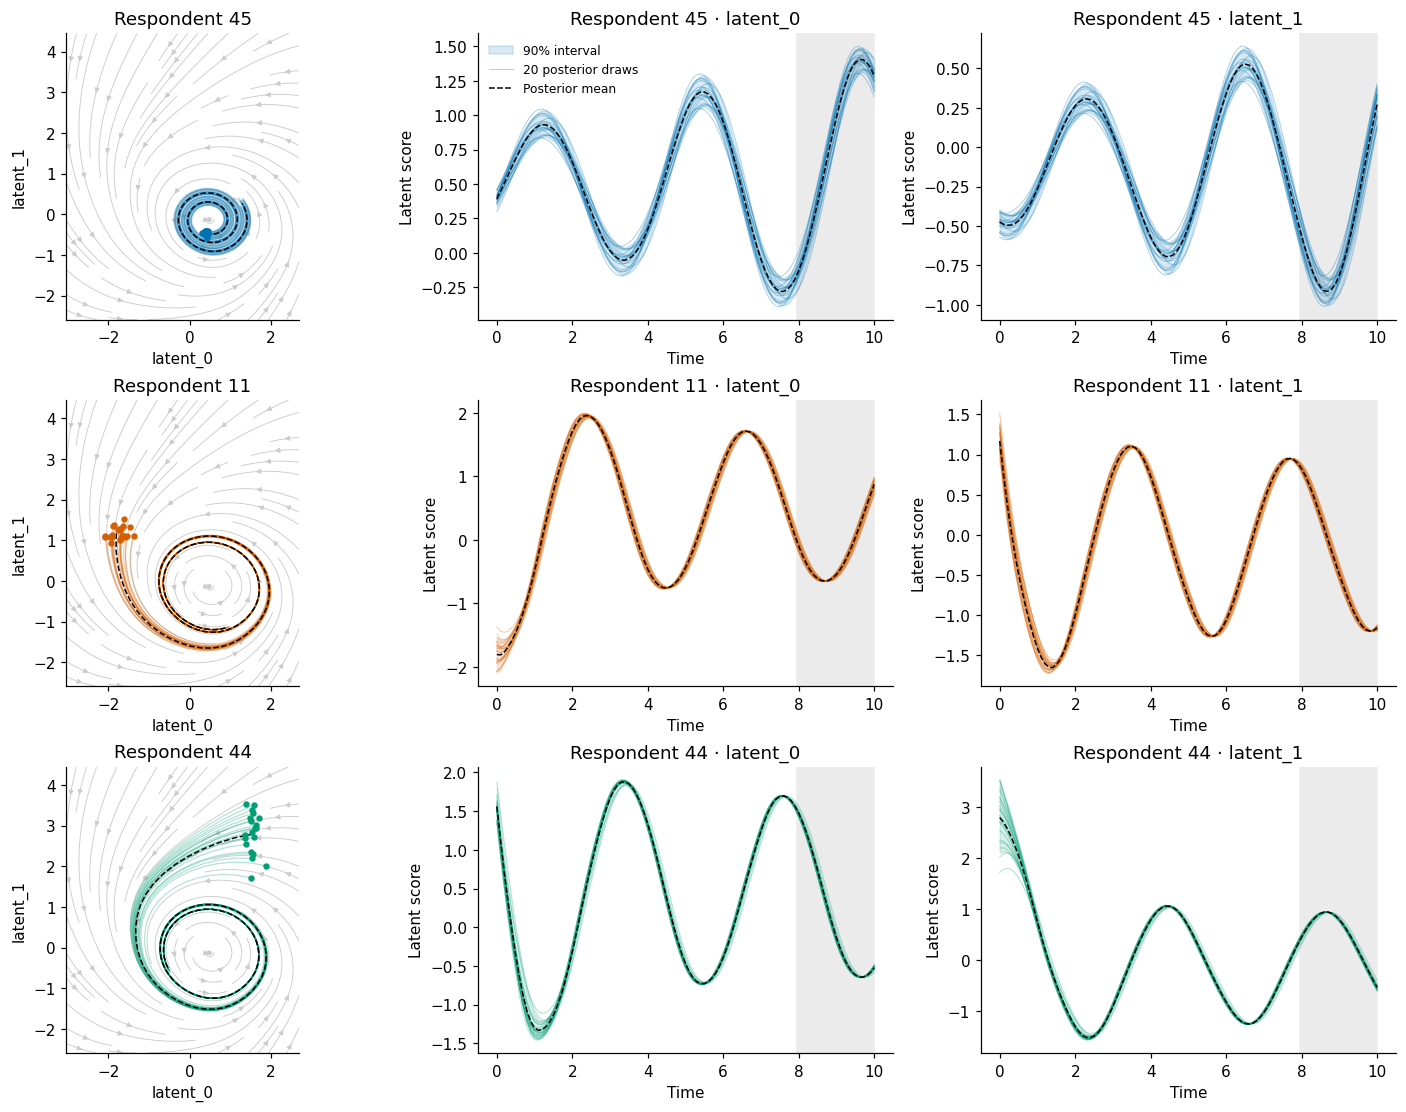

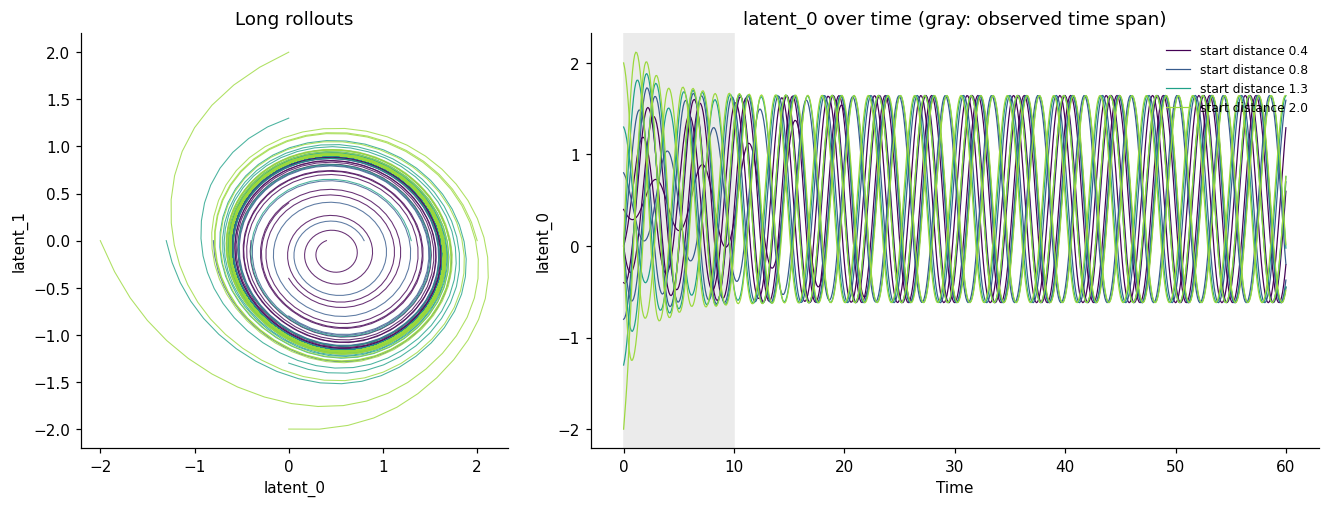

In [18]:
plot_respondents(network_sparse, paths_sparse)
plot_rollouts(network_sparse)